# Object Detection

In [1]:
def detect(image_name):
    # importing libraries for image handling and visualization
    from PIL import Image # for opening input image
    import matplotlib.pyplot as plt # for displaying the input image and for result visualization
    import cv2
    
    #using ultralytics libraries to fetch YOLO 11nano version lightweight object detection model
    from ultralytics import YOLO
    
    # loading the pretrained model
    model = YOLO("yolo11n.pt")
    
    # setting up the image path
    image_path = f"../images/" + image_name + ".jpg"
    
    # load the image
    image = Image.open(image_path)
    
    # runing the pretrained model on the test image
    results = model(image)
    
    # for first image (test image)
    result = results[0]
    
    # Extracting detection information
    
    # getting the predicted class label
    class_ids = result.boxes.cls
    
    # getting the bounding box coordinates
    # each box coordinate is [x1,y1,x2,y2]
    boxes = result.boxes.xyxy
    
    # getting the confidecn score for each detection
    confidences = result.boxes.conf
    
    # displaying the predictions
    for class_id, box, confidence in zip(class_ids,boxes,confidences): # ask questions
        # converting the class id from tensor value to integer
        class_id = int(class_id)
        # converting the bounding box coordinates to a list
        box = box.tolist()
    
        # converting the confidence score to regular decimal value
        confidence = float(confidence)
    
        # getting the class label name
        class_name = result.names[class_id]
    
        # Display the prediction information.
        print(f"Class ID: {class_id}")
        print(f"Class Name: {class_name}")
        print(f"Bounding Box: {box}")
        print(f"Confidence: {confidence:.2f}")
        print("-" * 40)
    
    # generating annotated image containing
    # the detected object, boxes, names and confidence
    annotated_image = result.plot(color_mode = "instance")
    
    # overwrite the default color code of the ultralystics
    annotated_image = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )

    # ============================================================
    # DISPLAY SIDE-BY-SIDE
    # ============================================================
    # size of figure
    figsize=(8,6)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title("Input Image")
    axes[0].axis("off")
    
    # YOLO detection result
    axes[1].imshow(annotated_image)
    axes[1].set_title(f"Detection Result")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()



0: 480x640 1 cat, 1 dog, 221.8ms
Speed: 9.4ms preprocess, 221.8ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)
Class ID: 16
Class Name: dog
Bounding Box: [98.20753479003906, 4.22860050201416, 347.2413635253906, 299.3414001464844]
Confidence: 0.75
----------------------------------------
Class ID: 15
Class Name: cat
Bounding Box: [98.24500274658203, 4.358856201171875, 345.7474670410156, 299.2943115234375]
Confidence: 0.59
----------------------------------------


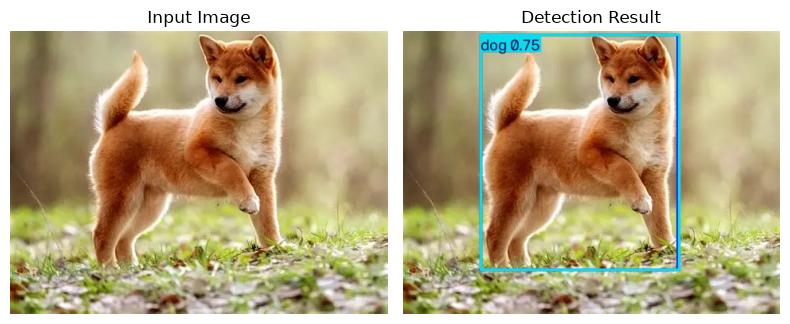

In [2]:
detect("test2")


0: 448x640 1 zebra, 255.7ms
Speed: 6.8ms preprocess, 255.7ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)
Class ID: 22
Class Name: zebra
Bounding Box: [147.9502410888672, 1.774828314781189, 416.48980712890625, 301.6578369140625]
Confidence: 0.93
----------------------------------------


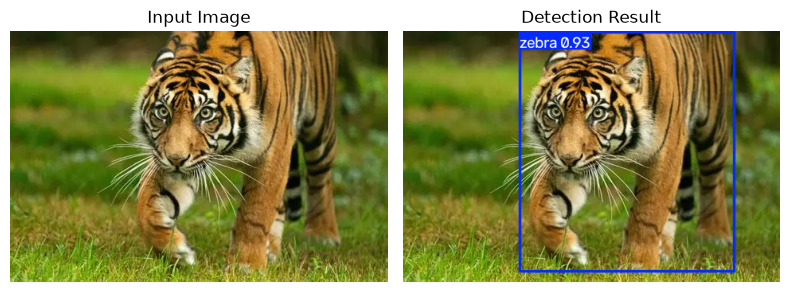

In [3]:
detect("test")


0: 448x640 1 airplane, 122.4ms
Speed: 9.0ms preprocess, 122.4ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)
Class ID: 4
Class Name: airplane
Bounding Box: [446.8614501953125, 361.3572998046875, 2692.1748046875, 1939.3167724609375]
Confidence: 0.92
----------------------------------------


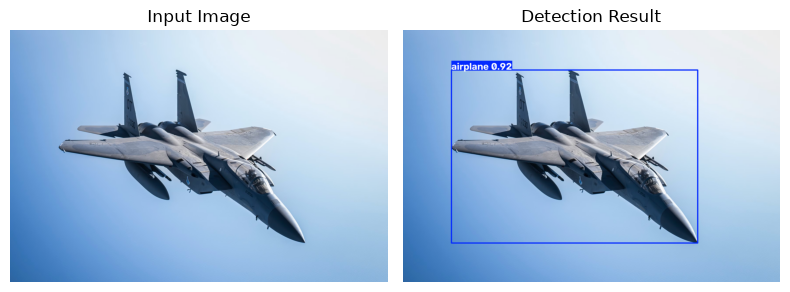

In [4]:
detect("test3")